# ARIM-Academy：CNNによるSEM画像からのナノ構造体の分類 ― LeNet-5から現代的CNNへ
### 機器：走査電子顕微鏡（SEM）
### 分析：畳み込みニューラルネットワーク（CNN）

## このノートブックについて

| 項目 | 内容 |
| --- | --- |
| **対象読者** | `1_LeNet-5.ipynb` を終えた方。Kerasで層を積む書き方（`Sequential`、`compile`／`fit`／`evaluate`／`predict`、コールバック）を一度たどったことがある方 |
| **前提知識** | 統計学・機械学習の予備知識は前提としません。1冊目で導入した評価の枠組み（訓練/検証/テストの3分割、多数派ベースライン、balanced accuracy、macro-F1）はそのまま使います |
| **学べること** | ①LeNet-5の設計を現代化すると何が起きるか、②画像データセットの実態を数字で確認する手順、③クラス不均衡データでの正しい評価指標の選び方、④ハイパーパラメータ探索を「テストデータを汚さずに」行う方法 |
| **動作環境** | Google Colab（GPUランタイム推奨）または ローカルの Python 3.10+ / TensorFlow 2.16+ / OpenCV / scikit-learn / pandas / matplotlib / seaborn |
| **所要時間** | GPU環境で約15〜25分（ハイパーパラメータ探索を含む） |
| **データのライセンス** | 原データセットは CC BY 4.0（Aversa et al., *Sci Data* 5, 180172, 2018）。本教材ではその一部（1,705枚）を再配布しています |
| **本ノートブックのライセンス** | MIT License |
| **バージョン** | 第2版（2026-07-26 改訂） |

### シリーズ全3冊の地図

| # | ノートブック | ねらい |
| --- | --- | --- |
| 1 | `1_LeNet-5.ipynb` | **歴史編・文法編**：1998年のLeNet-5を原典に忠実に再現し、Kerasで層を組む文法を1つずつ習得する |
| 2 | `2_CNN.ipynb` ←**本書** | **現代化編**：LeNet-5を出発点に、解像度・活性化関数・プーリング・正則化を現代的な設計へ更新し、ハイパーパラメータを探索する |
| 3 | `3_Xception.ipynb` | **転移学習編**：ImageNetで事前学習されたXceptionを流用し、ゼロから学習したCNNと比較する |

3冊は**この順に読む前提**で書かれています。前の冊で導入した用語・評価の枠組み（多数派ベースライン、balanced accuracy、macro-F1、訓練/検証/テストの3分割）は、後の冊でも同じ意味で使います。ただしコードはそれぞれ独立して実行できるよう、セットアップとデータ読み込みは各冊に再掲しています。

### 1冊目からの続き ― 本書で何を変えるのか

`1_LeNet-5.ipynb` では、1998年のLeNet-5を原典に忠実に組み立て、**構造は変えずに**部品（活性化関数・プーリング・最適化アルゴリズム）だけを現代化する実験を行いました。そこで残った課題が、本書の出発点です。

| 1冊目で見えた限界 | 本書での対処 | 扱う節 |
| --- | --- | --- |
| **入力32×32では微細構造が消える** | 入力を **100×100** に拡大する | 2節 |
| **特徴マップが6枚・16枚では表現力が足りない** | **32枚・64枚・64枚** に増やす | 5節 |
| **層構成が入力サイズに縛られている**（C5でちょうど1×1に収束する設計） | `Flatten` の前で無理に1×1まで縮めず、素直に平坦化する | 5節 |
| **データセットの素性を確認していない** | クラス不均衡・情報バーを実データで検証する | 1節 |
| **手作業で1つずつ試すのは非効率** | 12通りの構成を総当たりで探索する | 6節 |
| **過学習への対処がない** | EarlyStopping で最良時点に巻き戻す | 5節 |

**変えないもの**：訓練/検証/テストの3分割の作り方、乱数シード、評価指標（accuracy・balanced accuracy・macro-F1）、多数派ベースラインとの比較。**テストデータの中身も1冊目と完全に同一**です（分割チェックサムで確認できます）。純粋に「モデル設計の違い」だけを比較できるようにするためです。

> **用語について**：1冊目のモデルは「LeNet-5」という固有名を持つ歴史的なアーキテクチャでした。本書で作るのは特定の論文に対応する名前付きモデルではなく、**LeNet-5の考え方（畳み込み＋プーリングを重ねて最後に全結合）を受け継いだ、現代的な小規模CNN**です。本書ではこれを単に「CNN」と呼びます。

## データセット

『ナノ構造体のSEMデータセット』は、イタリア CNR-IOM（トリエステ）の TASC 研究所で、約100名の研究者が5年間かけて ZEISS SUPRA 40 電界放出型SEM で取得した画像を、人手でアノテーションした公開データセットです[1]。公開されている **Majority dataset は 21,272 枚**（論文本文では「約22,000枚」と記載）で、10カテゴリに分類されています。カテゴリは0D物体（粒子）、1D構造（ナノワイヤ・繊維）、2D構造（膜・コーティング表面・パターン表面）、3D構造（MEMSデバイス等）に加え、探針（Tips）や生物試料（Biological）を含みます。

> **本教材で配布しているのは全データではありません。**
> リポジトリに同梱しているのは全21,272枚のうち **1,705枚**（`data/training_data/`）だけです。セミナー時間内に学習を完了させるための抜粋であり、後述するとおり**カテゴリごとの枚数が大きく偏っています**。この点は評価結果の解釈に直結するので、3節で必ず数字を確認します。

[1] Rossella Aversa, Mohammad Hadi Modarres, Stefano Cozzini, Regina Ciancio & Alberto Chiusole, *The first annotated set of scanning electron microscopy images for nanoscience*, **Scientific Data 5, 180172 (2018)**, DOI: [10.1038/sdata.2018.172](https://doi.org/10.1038/sdata.2018.172)（CC BY 4.0）

<img src="./img/image.png" width="50%" alt="メインイメージ">

## 0. セットアップ

### Google Colab で実行する場合

次のセルを実行すると、教材一式（ノートブック・画像データ）を Colab の作業領域に取得します。
<font color="red">ローカル環境で実行する場合は、このセルを実行する必要はありません。</font>

In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_NAME = "Advanced_Tutorial_1_SEM-Image-Classification"
    if not Path(REPO_NAME).exists():
        !git clone --depth 1 https://github.com/ARIM-Academy-ImageRecognition/Advanced_Tutorial_1_SEM-Image-Classification.git
    %cd {REPO_NAME}

print(f"Running on Google Colab: {IN_COLAB}")
print(f"Current working directory: {Path.cwd()}")

Running on Google Colab: False
Current working directory: c:\Users\a013662\Dropbox\ARIM\1_ARIM-Academy-ImageRecognition\Advanced_Tutorial_1_SEM-Image-Classification


### GPUの確認

学習にはGPUを使うと数倍〜十数倍速くなります。Colabでは「ランタイム」→「ランタイムのタイプを変更」→ ハードウェアアクセラレータに **GPU** を選択してください。GPUが無くても本ノートブックは動きますが、CPUのみだと数倍の時間がかかります。

In [2]:
import tensorflow as tf

gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
    # メモリを一度に占有せず、必要な分だけ確保する設定（複数プロセスでの競合を避ける）
    for gpu in gpu_devices:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU detected: {[d.name for d in gpu_devices]}")
else:
    print("No GPU detected. The notebook will run on CPU (slower).")
    print("On Colab: Runtime > Change runtime type > Hardware accelerator > GPU")

print(f"TensorFlow version: {tf.__version__}")

No GPU detected. The notebook will run on CPU (slower).
On Colab: Runtime > Change runtime type > Hardware accelerator > GPU
TensorFlow version: 2.21.0


### ライブラリのインポートと共通設定

深層学習は乱数（重みの初期値、データのシャッフル順など）に依存します。結果を再現できるよう、乱数シードを一箇所にまとめて固定します。

> **注意**：GPU上の一部の演算は非決定的なため、シードを固定しても実行のたびに小数点以下が変動することがあります。「毎回まったく同じ数値になる」とは限りません。傾向が再現できれば十分です。

In [3]:
import os
import random
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print("Libraries imported. Random seed fixed to", SEED)

Libraries imported. Random seed fixed to 42


### 入出力フォルダの準備

生成物（前処理済みデータ・学習済みモデル・図・CSV）はノートブックと同じ階層に散らかさず、`output/` と `model/` にまとめます。フォルダが無ければ自動で作成します。

In [4]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
TRAIN_DIR = DATA_DIR / "training_data"
PREDICT_DIR = DATA_DIR / "prediction_data"

OUTPUT_DIR = BASE_DIR / "output"
MODEL_DIR = BASE_DIR / "model"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

assert TRAIN_DIR.exists(), f"Training data not found at {TRAIN_DIR}"

print(f"Data directory  : {TRAIN_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Model directory : {MODEL_DIR}")

Data directory  : c:\Users\a013662\Dropbox\ARIM\1_ARIM-Academy-ImageRecognition\Advanced_Tutorial_1_SEM-Image-Classification\data\training_data
Output directory: c:\Users\a013662\Dropbox\ARIM\1_ARIM-Academy-ImageRecognition\Advanced_Tutorial_1_SEM-Image-Classification\output
Model directory : c:\Users\a013662\Dropbox\ARIM\1_ARIM-Academy-ImageRecognition\Advanced_Tutorial_1_SEM-Image-Classification\model


## 1. データセットの実態を確認する

機械学習では、モデルを作る前に**データの中身を数字で確認する**ことが何より重要です。ここでは次の3点を確認します。

1. カテゴリ（フォルダ）ごとの画像枚数 → クラス不均衡の有無
2. 画像のサイズと形式
3. SEM画像特有の「情報バー（データバー）」の存在

In [5]:
# 分類ラベルはフォルダ名をそのまま使う（10カテゴリ）
CATEGORIES = ["Biological", "Fibres",
              "Films_Coated_Surface", "MEMS_devices_and_electrodes",
              "Nanowires", "Particles",
              "Patterned_surface", "Porous_Sponge",
              "Powder", "Tips"]

NUM_CLASSES = len(CATEGORIES)

# CNNへの入力サイズ（1辺のピクセル数）
IMG_SIZE = 100

image_paths = {c: sorted((TRAIN_DIR / c).glob("*.jpg")) for c in CATEGORIES}
counts = pd.Series({c: len(p) for c, p in image_paths.items()}, name="n_images")

summary = counts.to_frame()
summary["ratio_%"] = (summary["n_images"] / summary["n_images"].sum() * 100).round(1)
print(summary)
print(f"\nTotal images: {counts.sum()}")
print(f"Most frequent class: {counts.idxmax()} ({counts.max()} images, "
      f"{counts.max() / counts.sum():.1%} of the dataset)")
print(f"Least frequent class: {counts.idxmin()} ({counts.min()} images)")

                             n_images  ratio_%
Biological                        100      5.9
Fibres                            100      5.9
Films_Coated_Surface              100      5.9
MEMS_devices_and_electrodes       100      5.9
Nanowires                         100      5.9
Particles                         100      5.9
Patterned_surface                 100      5.9
Porous_Sponge                     100      5.9
Powder                            895     52.5
Tips                               10      0.6

Total images: 1705
Most frequent class: Powder (895 images, 52.5% of the dataset)
Least frequent class: Tips (10 images)


### クラス不均衡という落とし穴

上の表を見ると、`Powder` が全体の半分以上を占め、`Tips` はわずか10枚しかありません。

このとき「**何も学習せず、常に `Powder` と答えるだけのモデル**」でも正解率（accuracy）は約52.5%に達します。これを **多数派ベースライン（majority-class baseline）** と呼びます。つまり「正解率70%」という結果が出ても、それが本当に学習の成果なのかは、このベースラインと比べなければ判断できません。

本ノートブックでは、正解率に加えて次の指標を必ず併記します。

- **balanced accuracy（バランス精度）**：クラスごとの再現率（recall）の平均。少数クラスを無視すると下がる
- **macro-F1**：クラスごとのF1スコアの単純平均。同じく少数クラスを重く見る

いずれも「全クラスを平等に扱う」指標で、不均衡データでの実力を測るのに適しています。

In [6]:
majority_baseline = counts.max() / counts.sum()
print(f"Majority-class baseline accuracy = {majority_baseline:.4f} "
      f"(always predicting '{counts.idxmax()}')")
print(f"Majority-class baseline balanced accuracy = {1 / NUM_CLASSES:.4f}")
print(f"Random-guess accuracy (uniform over {NUM_CLASSES} classes) = {1 / NUM_CLASSES:.4f}")

Majority-class baseline accuracy = 0.5249 (always predicting 'Powder')
Majority-class baseline balanced accuracy = 0.1000
Random-guess accuracy (uniform over 10 classes) = 0.1000


### 図1：カテゴリごとの画像枚数

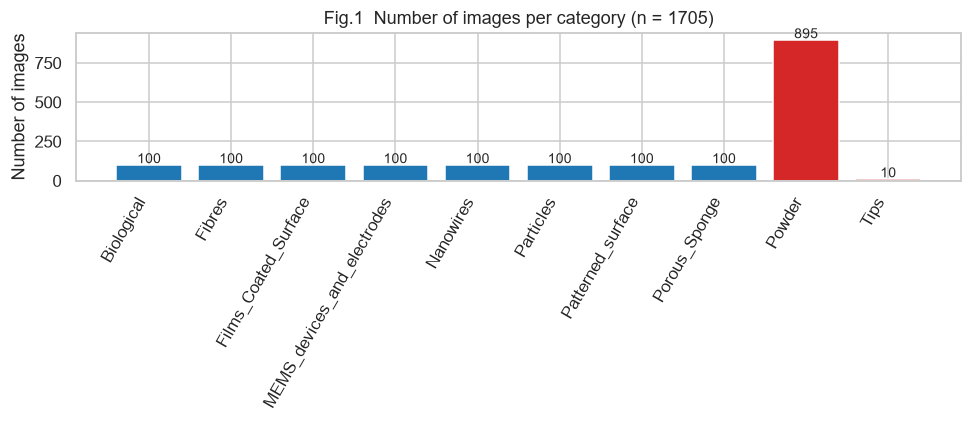

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ["tab:red" if c in (counts.idxmax(), counts.idxmin()) else "tab:blue"
              for c in counts.index]
ax.bar(counts.index, counts.values, color=bar_colors)
ax.set_ylabel("Number of images")
ax.set_title(f"Fig.1  Number of images per category (n = {counts.sum()})")
ax.tick_params(axis="x", rotation=60)
for x, v in enumerate(counts.values):
    ax.text(x, v + 12, str(v), ha="center", fontsize=9)
plt.setp(ax.get_xticklabels(), ha="right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig01_class_distribution.png", dpi=150)
plt.show()

### 情報バー（データバー）の存在

このデータセットの画像はいずれも **1,024 × 768 ピクセル**で、画像の下部に測定条件を記した白い帯（情報バー／データバー）が焼き込まれています。加速電圧（EHT）、ワーキングディスタンス（WD）、倍率（Mag）、検出器の種類（Signal A）などが読み取れます。

この帯を残したまま学習させると何が起きるでしょうか。情報バーの文字列（特に倍率）は試料の種類と相関しているため、CNNが**試料の形態ではなく文字の並びを覚えてしまう**危険があります。これは典型的な **ショートカット学習（shortcut learning）** で、見かけの精度は上がるのに、別の装置で撮った画像ではまったく当たらないモデルができあがります。

そこで前処理として情報バーを切り落とします。次のセルで、バーが画像のどの行に現れるかを実データで確認します。

In [8]:
def find_databar_rows(gray_image, brightness_threshold=200, coverage=0.5,
                      search_from=0.7, min_height=20, max_height=150):
    """行ごとに「明るい画素の割合」を調べ、情報バーに相当する連続した明るい帯を返す。

    誤検出を避けるため、画像の下側（search_from 以降）だけを探索し、
    高さが min_height〜max_height の帯だけを情報バーとみなす。

    戻り値は (開始行, 終了行) のタプル。見つからない場合は None。
    """
    height = gray_image.shape[0]
    offset = int(height * search_from)
    lower_part = gray_image[offset:, :]

    bright_rows = (lower_part > brightness_threshold).mean(axis=1) > coverage
    indices = np.where(bright_rows)[0]
    if indices.size == 0:
        return None

    # 連続した行のかたまりに分割し、最も長いものを情報バーの候補とする
    runs = np.split(indices, np.where(np.diff(indices) != 1)[0] + 1)
    longest = max(runs, key=len)
    if not (min_height <= len(longest) <= max_height):
        return None
    return int(longest[0]) + offset, int(longest[-1]) + offset


sample_path = image_paths["Biological"][0]
sample_gray = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)

print(f"Sample file : {sample_path.name}")
print(f"Image shape : {sample_gray.shape} (height, width)")
print(f"Dtype / range: {sample_gray.dtype}, min={sample_gray.min()}, max={sample_gray.max()}")
print(f"Detected databar rows: {find_databar_rows(sample_gray)}")

Sample file : L7_00dd57885a938436a606506fc7620bd9.jpg
Image shape : (768, 1024) (height, width)
Dtype / range: uint8, min=0, max=255
Detected databar rows: (638, 697)


In [9]:
# 複数カテゴリで情報バーの位置が共通かどうかを確認する
for category in CATEGORIES:
    gray = cv2.imread(str(image_paths[category][0]), cv2.IMREAD_GRAYSCALE)
    print(f"{category:30s} shape={gray.shape}  databar_rows={find_databar_rows(gray)}")

Biological                     shape=(768, 1024)  databar_rows=(638, 697)
Fibres                         shape=(768, 1024)  databar_rows=(655, 713)
Films_Coated_Surface           shape=(768, 1024)  databar_rows=(631, 690)
MEMS_devices_and_electrodes    shape=(768, 1024)  databar_rows=(676, 749)
Nanowires                      shape=(768, 1024)  databar_rows=(631, 690)
Particles                      shape=(768, 1024)  databar_rows=(638, 697)
Patterned_surface              shape=(768, 1024)  databar_rows=(636, 695)
Porous_Sponge                  shape=(768, 1024)  databar_rows=(638, 697)
Powder                         shape=(768, 1024)  databar_rows=(638, 697)
Tips                           shape=(768, 1024)  databar_rows=(638, 697)


検証したところ、情報バーはどのカテゴリでも **636〜698行目**（高さ約60ピクセル）に現れました。そこで安全側に倒し、**上から630行目まで**（`image[:630, :]`）を残して切り取ることにします。バーの下にわずかに残る画像領域も一緒に捨てますが、視野の一部を失うだけで害はありません。

> **実装上のポイント**：`cv2.resize()` の補間方法は既定で `INTER_LINEAR` ですが、1024×630 → 100×100 のように**縮小**するときは `INTER_AREA` のほうが折り返し歪み（エイリアシング）が少なく適切です。

In [10]:
# 実測に基づく定数：情報バーは 636 行目付近から始まるため、余裕をみて 630 行目で切る
DATABAR_TOP_ROW = 630


def load_micrograph(path, img_size=IMG_SIZE, crop_databar=True, as_rgb=False):
    """SEM画像を1枚読み込み、情報バーを除去して正方形にリサイズする。

    Parameters
    ----------
    path : str or Path
        画像ファイルのパス
    img_size : int
        リサイズ後の1辺のピクセル数
    crop_databar : bool
        True なら下部の情報バーを切り落とす
    as_rgb : bool
        True なら3チャンネル（RGB）で返す。False ならグレースケール1チャンネル

    Returns
    -------
    numpy.ndarray
        形状 (img_size, img_size, 1) または (img_size, img_size, 3) の uint8 配列
    """
    flag = cv2.IMREAD_COLOR if as_rgb else cv2.IMREAD_GRAYSCALE
    image = cv2.imread(str(path), flag)
    if image is None:
        raise ValueError(f"Failed to read image: {path}")

    if as_rgb:
        # OpenCV は BGR 順で読み込むため、RGB 順に並べ替える
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    if crop_databar and image.shape[0] > DATABAR_TOP_ROW:
        image = image[:DATABAR_TOP_ROW, :]

    resized = cv2.resize(image, (img_size, img_size), interpolation=cv2.INTER_AREA)
    if not as_rgb:
        resized = resized[:, :, np.newaxis]
    return resized

### 図2：情報バー除去の効果

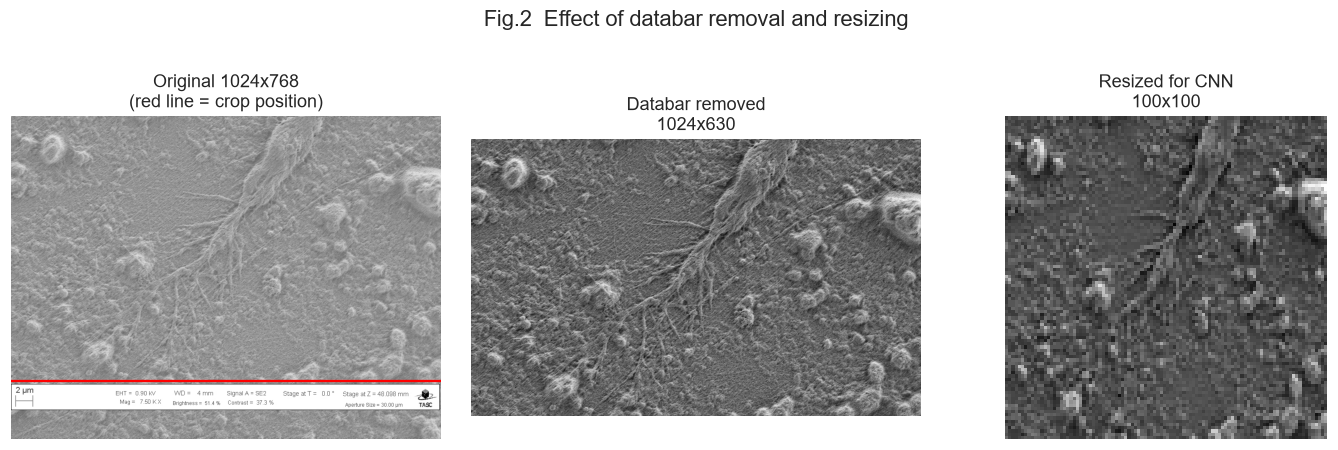

In [11]:
raw = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)
cropped = raw[:DATABAR_TOP_ROW, :]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(raw, cmap="gray")
axes[0].axhline(DATABAR_TOP_ROW, color="red", lw=1.5)
axes[0].set_title("Original 1024x768\n(red line = crop position)")

axes[1].imshow(cropped, cmap="gray")
axes[1].set_title(f"Databar removed\n{cropped.shape[1]}x{cropped.shape[0]}")

axes[2].imshow(load_micrograph(sample_path).squeeze(), cmap="gray")
axes[2].set_title(f"Resized for CNN\n{IMG_SIZE}x{IMG_SIZE}")

for ax in axes:
    ax.axis("off")
fig.suptitle("Fig.2  Effect of databar removal and resizing", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig02_databar_removal.png", dpi=150, bbox_inches="tight")
plt.show()

### 図3：各カテゴリの代表画像

10カテゴリがどのような見た目なのかを一覧します。「粉体（Powder）」と「多孔質スポンジ（Porous_Sponge）」、「粒子（Particles）」の区別が人間の目にも難しいことに注目してください。後で混同行列を読むときの手がかりになります。

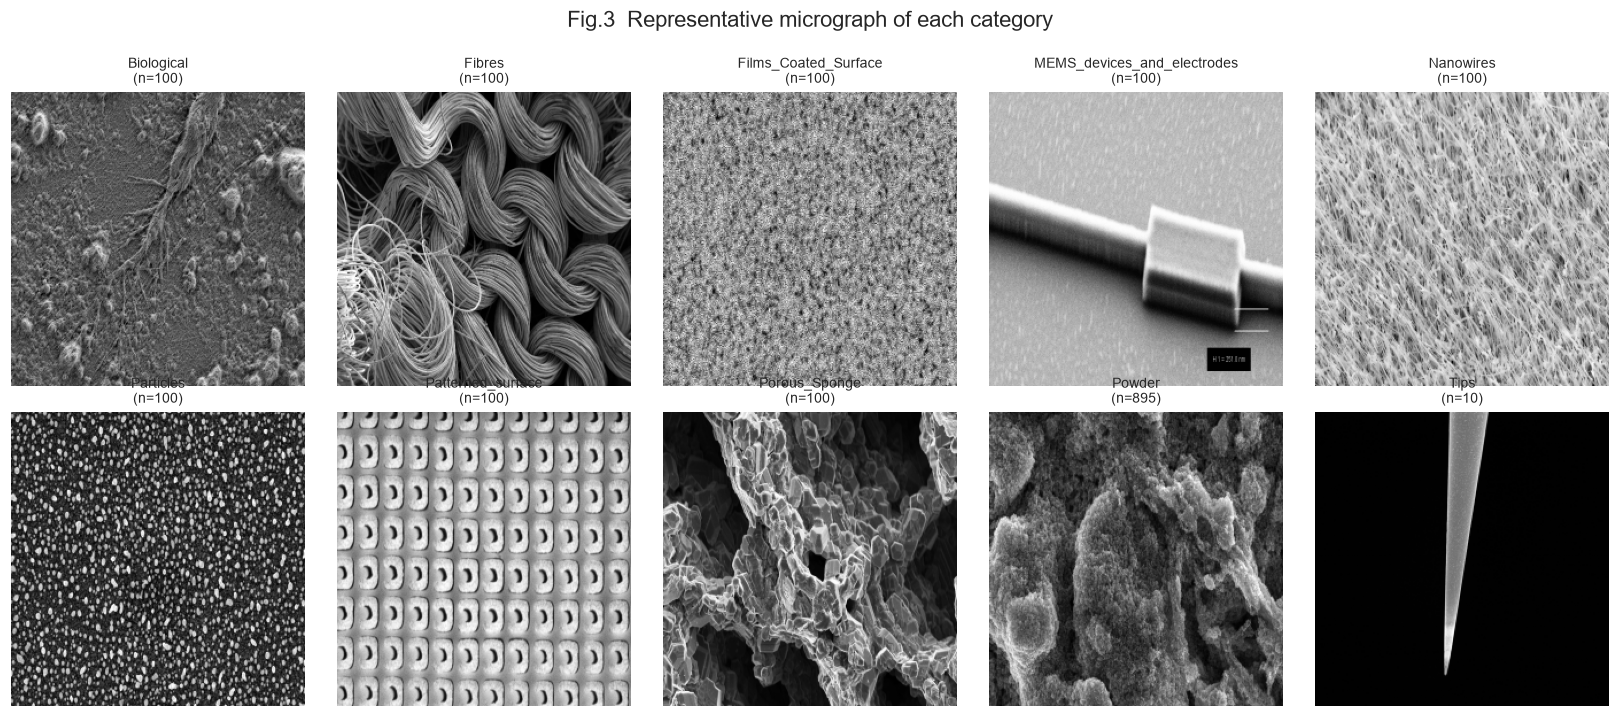

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
for ax, category in zip(axes.ravel(), CATEGORIES):
    ax.imshow(load_micrograph(image_paths[category][0], img_size=256).squeeze(), cmap="gray")
    ax.set_title(f"{category}\n(n={counts[category]})", fontsize=9)
    ax.axis("off")
fig.suptitle("Fig.3  Representative micrograph of each category", y=1.0)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig03_category_examples.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. データセットの読み込みとキャッシュ

1,705枚すべてを読み込み、NumPy配列にまとめます。読み込みには数十秒かかるので、結果を `output/` に **`.npz` 形式**で保存し、2回目以降は即座に読み出せるようにします。

> **なぜ pickle ではなく npz なのか**：`pickle` は「Pythonオブジェクトを何でも保存できる」便利さの裏返しとして、**読み込み時に任意のコードを実行できてしまう**という安全上の弱点があります。配布物やネットからダウンロードした `.pickle` を無警戒に開くのは危険です。数値配列だけを保存するなら `numpy.savez_compressed()` のほうが安全かつ高速です。

In [13]:
def build_dataset(categories, img_size=IMG_SIZE, as_rgb=False, verbose=True):
    """カテゴリ別フォルダから全画像を読み込み、特徴量Xとラベルyを返す。

    Returns
    -------
    X : numpy.ndarray, shape (n_samples, img_size, img_size, channels), dtype=uint8
    y : numpy.ndarray, shape (n_samples,), dtype=int64
    """
    images, labels, failures = [], [], []

    for class_index, category in enumerate(categories):
        paths = sorted((TRAIN_DIR / category).glob("*.jpg"))
        for path in paths:
            try:
                images.append(load_micrograph(path, img_size=img_size, as_rgb=as_rgb))
                labels.append(class_index)
            except ValueError as error:
                failures.append((path.name, str(error)))
        if verbose:
            print(f"  {category:30s} loaded {len(paths):4d} images")

    if failures:
        print(f"\nWARNING: {len(failures)} image(s) could not be read:")
        for name, message in failures[:5]:
            print(f"  - {name}: {message}")

    X = np.stack(images).astype(np.uint8)
    y = np.asarray(labels, dtype=np.int64)
    return X, y


CACHE_PATH = OUTPUT_DIR / f"sem_dataset_gray_{IMG_SIZE}.npz"

start = time.time()
if CACHE_PATH.exists():
    with np.load(CACHE_PATH) as cached:
        X, y = cached["X"], cached["y"]
    print(f"Loaded cached dataset from {CACHE_PATH.name}")
else:
    X, y = build_dataset(CATEGORIES)
    np.savez_compressed(CACHE_PATH, X=X, y=y)
    print(f"Saved dataset cache to {CACHE_PATH.name}")

print(f"Elapsed: {time.time() - start:.1f} s")
print(f"X: shape={X.shape}, dtype={X.dtype}, range=[{X.min()}, {X.max()}]")
print(f"y: shape={y.shape}, dtype={y.dtype}, classes={np.unique(y).tolist()}")
print(f"Memory used by X: {X.nbytes / 1e6:.1f} MB")

  Biological                     loaded  100 images
  Fibres                         loaded  100 images
  Films_Coated_Surface           loaded  100 images
  MEMS_devices_and_electrodes    loaded  100 images
  Nanowires                      loaded  100 images
  Particles                      loaded  100 images
  Patterned_surface              loaded  100 images
  Porous_Sponge                  loaded  100 images
  Powder                         loaded  895 images
  Tips                           loaded   10 images
Saved dataset cache to sem_dataset_gray_100.npz
Elapsed: 39.6 s
X: shape=(1705, 100, 100, 1), dtype=uint8, range=[0, 255]
y: shape=(1705,), dtype=int64, classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Memory used by X: 17.1 MB


> **画素値のスケーリングについて**：`X` は 0〜255 の `uint8` のまま保持します。0〜1への正規化は、後で**モデルの中の `Rescaling` 層**として組み込みます。こうしておくと「学習時は割ったのに、推論時に割り忘れた」という典型的なバグが原理的に起こりません（この教材の初版には、まさにそのバグがありました）。

## 3. データセットの分割（訓練 / 検証 / テスト）

機械学習の評価では、データを分けて使います。ここで**3分割**にするのが本ノートブックの重要な設計判断です。

| 分割 | 用途 | 本ノートブックでの割合 |
| --- | --- | --- |
| 訓練（train） | モデルの重みを学習する | 60% |
| 検証（validation） | 学習の打ち切り判断・ハイパーパラメータの選択 | 20% |
| テスト（test） | 最後に一度だけ使う「最終試験」 | 20% |

**なぜ2分割ではだめなのか。** 「訓練とテストの2分割」で、テストデータを毎エポックの検証に使い、さらに「テスト精度が一番良かったモデル」を選んでしまうと、テストデータの情報がモデル選択を通じて漏れ込みます（**選択バイアス**）。その結果、報告される精度は実力より高く出ます。本書は6節でハイパーパラメータを12通り試すので、この問題を避けることが特に重要になります。

**`stratify` を指定する理由。** `Tips` は全体で10枚しかありません。単純なランダム分割では、分割によっては訓練データに `Tips` が1枚も入らない、という事故が起こり得ます。`stratify=y` を指定すると、各分割のクラス構成比が元データと同じになるよう調整されます。

In [14]:
# 画像そのものではなく「インデックス」を分割する。
# こうしておくと、1_LeNet-5.ipynb・3_Xception.ipynb でも同じ関数・同じシードで
# まったく同じ分割を再現できる。
all_indices = np.arange(len(y))

# 1回目：train+val（80%）とtest（20%）に分ける
idx_trainval, idx_test = train_test_split(
    all_indices, test_size=0.2, random_state=SEED, stratify=y)

# 2回目：train+val をさらに train（75%）とval（25%）に分ける → 全体の60% / 20%
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.25, random_state=SEED, stratify=y[idx_trainval])

X_train, y_train = X[idx_train], y[idx_train]
X_val, y_val = X[idx_val], y[idx_val]
X_test, y_test = X[idx_test], y[idx_test]

# 分割が重複していないことを確認する（データリーケージの初歩的な検算）
assert len(set(idx_train) & set(idx_val)) == 0
assert len(set(idx_train) & set(idx_test)) == 0
assert len(set(idx_val) & set(idx_test)) == 0
print(f"Split checksum (sum of test indices) = {idx_test.sum()}")
print("-> This value must match the checksum printed in 1_LeNet-5.ipynb and 3_Xception.ipynb.")

for name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s}: {len(labels):5d} samples ({len(labels) / len(y):.0%})")

split_table = pd.DataFrame(
    {name: pd.Series(labels).value_counts().sort_index().values
     for name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]},
    index=CATEGORIES)
split_table["total"] = split_table.sum(axis=1)
print()
print(split_table)

Split checksum (sum of test indices) = 290658
-> This value must match the checksum printed in 1_LeNet-5.ipynb and 3_Xception.ipynb.
train:  1023 samples (60%)
val  :   341 samples (20%)
test :   341 samples (20%)

                             train  val  test  total
Biological                      60   20    20    100
Fibres                          60   20    20    100
Films_Coated_Surface            60   20    20    100
MEMS_devices_and_electrodes     60   20    20    100
Nanowires                       60   20    20    100
Particles                       60   20    20    100
Patterned_surface               60   20    20    100
Porous_Sponge                   60   20    20    100
Powder                         537  179   179    895
Tips                             6    2     2     10


### 図4：分割後のクラス構成

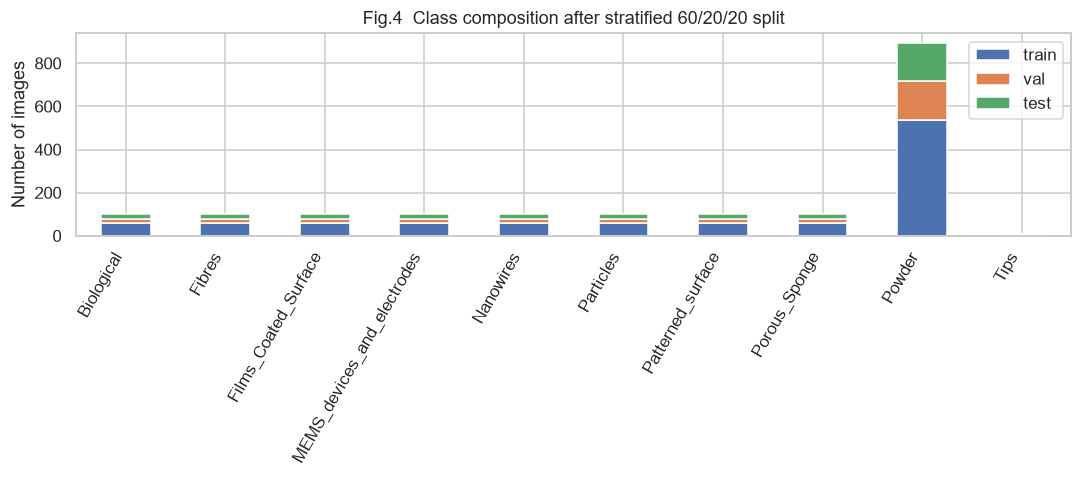

Test set: Tips has only 2 images -> per-class metrics for Tips are very unstable.


In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5))
split_table[["train", "val", "test"]].plot(kind="bar", stacked=True, ax=ax,
                                           color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Number of images")
ax.set_title("Fig.4  Class composition after stratified 60/20/20 split")
ax.tick_params(axis="x", rotation=60)
plt.setp(ax.get_xticklabels(), ha="right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig04_split_composition.png", dpi=150)
plt.show()

n_tips_test = int(split_table.loc["Tips", "test"])
print(f"Test set: Tips has only {n_tips_test} images "
      f"-> per-class metrics for Tips are very unstable.")

> **少数クラスの限界を正直に書いておく**：テストデータに含まれる `Tips` は **2枚だけ**です。2枚のうち1枚を間違えれば再現率は0.5、2枚とも当てれば1.0 と、値が飛び飛びにしか動きません。したがって `Tips` の個別スコアは「参考値」以上のものではありません。教材として、この限界は隠さずに扱います。

## 4. 評価用のヘルパー関数

評価のたびに同じコードを書くのは間違いのもとです。指標の計算と混同行列の描画を関数にまとめます。

**確率とロジット（logits）について。** 本ノートブックの出力層は活性化関数を付けず、生のスコア（**ロジット**）を出します。損失関数側で `from_logits=True` を指定すると、Kerasが内部で数値的に安定した形でソフトマックスと交差エントロピーをまとめて計算してくれます。人間が読む「確率」が欲しいときだけ、後から `tf.nn.softmax()` を適用します。

In [16]:
def predict_proba(model, features, batch_size=64):
    """モデルのロジット出力をソフトマックスで確率に変換して返す。"""
    logits = model.predict(features, batch_size=batch_size, verbose=0)
    return tf.nn.softmax(logits).numpy()


def evaluate_classifier(model, features, y_true, model_name, split_name):
    """分類モデルを評価し、主要指標を辞書で返す。"""
    y_proba = predict_proba(model, features)
    y_pred = np.argmax(y_proba, axis=1)

    scores = {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    return scores, y_pred, y_proba


def plot_confusion_matrix(y_true, y_pred, class_names, title, filename, normalize=True):
    """混同行列を描画して保存する。normalize=True では行方向（真のクラスごと）に正規化する。"""
    # scikit-learn の規約どおり、第1引数が正解、第2引数が予測
    matrix = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

    if normalize:
        row_sums = matrix.sum(axis=1, keepdims=True)
        display_matrix = np.divide(matrix, row_sums, where=row_sums != 0)
        fmt, vmax, cbar_label = ".2f", 1.0, "Recall (row-normalised)"
    else:
        display_matrix = matrix
        fmt, vmax, cbar_label = "d", None, "Number of images"

    fig, ax = plt.subplots(figsize=(8.5, 7))
    sns.heatmap(display_matrix, annot=True, fmt=fmt, square=True,
                cmap="Blues", vmin=0, vmax=vmax,
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={"label": cbar_label}, ax=ax)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()
    return matrix


def plot_learning_curves(history, title, filename):
    """学習曲線（損失と正解率）を並べて描画する。"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

    axes[0].plot(history.history["loss"], color="black", label="training")
    axes[0].plot(history.history["val_loss"], color="red", label="validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], color="black", label="training")
    axes[1].plot(history.history["val_accuracy"], color="red", label="validation")
    axes[1].axhline(majority_baseline, color="gray", ls="--",
                    label=f"majority baseline ({majority_baseline:.3f})")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()

print("Helper functions defined.")

Helper functions defined.


## 5. モデルA：ベースラインCNN

### 5.1 LeNet-5からの設計変更

1冊目のLeNet-5と、本書で作るCNNを並べます。**どの変更にも理由があります。**

| 項目 | LeNet-5（1冊目） | 本書のCNN | 変更の理由 |
| --- | --- | --- | --- |
| **入力** | 32×32 グレースケール | **100×100** グレースケール | 32×32ではナノワイヤ1本や粒子の輪郭が消えてしまう（1冊目の図2） |
| **畳み込み層** | 2層（6ch → 16ch） | **3層（32ch → 64ch → 64ch）** | 入力が大きくなった分、より多様な模様を捉える必要がある。層を1つ増やして受容野も広げる |
| **プーリング** | 平均プーリング | **最大プーリング** | 1冊目のアブレーションで効果を確認済み。強い反応を周囲の弱い反応で薄めない |
| **活性化関数** | tanh | **ReLU** | 勾配消失を避ける（1冊目の図6） |
| **最適化** | SGD | **Adam** | 学習率の手調整への依存を減らす |
| **`Flatten`前の設計** | C5でちょうど1×1まで縮める | 最後の畳み込み後にそのまま平坦化 | LeNet-5の「1×1に収束させる」設計は入力32×32に固く結びついている。入力サイズを変えられるよう素直な構成にする |
| **学習の打ち切り** | EarlyStopping | EarlyStopping（同じ） | 1冊目で導入済み |
| **前処理のスケール** | −1〜+1（tanh向け） | **0〜1** | ReLUは負の入力を0にするため、0中心にする必要がない |

**変えていないもの**：畳み込み → プーリング → 畳み込み → プーリング → …… → 平坦化 → 全結合、という**骨格そのもの**です。これはLeNet-5が1998年に確立した構成で、30年近く経った今も生き残っています。

### 5.2 レイヤー構成

`Rescaling(1/255)` をモデルの先頭に置き、0〜255 の画素値を 0〜1 に変換する処理をモデル自身に持たせています（1冊目と同じ考え方です。推論時の前処理の書き忘れを構造的に防ぎます）。

In [17]:
def build_simple_cnn(input_shape, num_classes,
                     conv_filters=(32, 64, 64), dense_units=(128, 64), name="simple_cnn"):
    """畳み込み層＋全結合層からなる小規模CNNを構築する。

    出力層は活性化関数を持たず、生のロジットを返す（損失側で from_logits=True を指定する）。
    """
    model = keras.Sequential(name=name)
    model.add(layers.Input(shape=input_shape))
    # 0-255 の画素値を 0-1 に変換する層。前処理をモデルに内蔵すると推論時の割り忘れを防げる
    model.add(layers.Rescaling(1.0 / 255))

    for index, filters in enumerate(conv_filters):
        model.add(layers.Conv2D(filters, (3, 3), activation="relu",
                                name=f"conv{index + 1}"))
        # 最後の畳み込み層の後にはプーリングを置かない（特徴マップが小さくなりすぎるため）
        if index < len(conv_filters) - 1:
            model.add(layers.MaxPooling2D((2, 2), name=f"pool{index + 1}"))

    model.add(layers.Flatten())
    for index, units in enumerate(dense_units):
        model.add(layers.Dense(units, activation="relu", name=f"dense{index + 1}"))

    model.add(layers.Dense(num_classes, name="logits"))
    return model


input_shape = (IMG_SIZE, IMG_SIZE, 1)
baseline_model = build_simple_cnn(input_shape, NUM_CLASSES)
baseline_model.summary()

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 100, 100, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 98, 98, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │     3,612,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,677,450 (14.03 MB)

 Trainable params: 3,677,450 (14.03 MB)

 Non-trainable params: 0 (0.00 B)

### コンパイルと学習

- **損失関数**：`SparseCategoricalCrossentropy(from_logits=True)`。ラベルが整数（0〜9）のときは `Sparse` 版を使います（one-hot に変換する必要がありません）。
- **最適化アルゴリズム**：Adam（学習率は既定の 0.001）
- **EarlyStopping**：検証損失が改善しなくなったら学習を打ち切り、**最も良かった時点の重みに戻します**（`restore_best_weights=True`）。初版は50エポック固定で、過学習した最終状態をそのまま使っていました。
- **ModelCheckpoint**：検証データで最良のモデルをファイルに保存します。

In [18]:
EPOCHS = 60
BATCH_SIZE = 64

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"])

baseline_ckpt = MODEL_DIR / "baseline_cnn.keras"
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ModelCheckpoint(baseline_ckpt, monitor="val_loss",
                                    save_best_only=True, verbose=0),
]

start = time.time()
baseline_history = baseline_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=2)
print(f"\nTraining finished in {time.time() - start:.1f} s "
      f"({len(baseline_history.history['loss'])} epochs)")

Epoch 1/60
16/16 - 7s - 461ms/step - accuracy: 0.4995 - loss: 1.7687 - val_accuracy: 0.5249 - val_loss: 1.6157
Epoch 2/60
16/16 - 5s - 288ms/step - accuracy: 0.5249 - loss: 1.5977 - val_accuracy: 0.5249 - val_loss: 1.6400
Epoch 3/60
16/16 - 5s - 337ms/step - accuracy: 0.5386 - loss: 1.5305 - val_accuracy: 0.5572 - val_loss: 1.5520
Epoch 4/60
16/16 - 5s - 315ms/step - accuracy: 0.5621 - loss: 1.4293 - val_accuracy: 0.5543 - val_loss: 1.4859
Epoch 5/60
16/16 - 5s - 307ms/step - accuracy: 0.5806 - loss: 1.3298 - val_accuracy: 0.5718 - val_loss: 1.3816
Epoch 6/60
16/16 - 4s - 277ms/step - accuracy: 0.6051 - loss: 1.2405 - val_accuracy: 0.5748 - val_loss: 1.4132
Epoch 7/60
16/16 - 5s - 288ms/step - accuracy: 0.6422 - loss: 1.1398 - val_accuracy: 0.6070 - val_loss: 1.4260
Epoch 8/60
16/16 - 5s - 294ms/step - accuracy: 0.6774 - loss: 1.0495 - val_accuracy: 0.6012 - val_loss: 1.4648
Epoch 9/60
16/16 - 5s - 338ms/step - accuracy: 0.7077 - loss: 0.9678 - val_accuracy: 0.6276 - val_loss: 1.3372
E

### 図5：モデルAの学習曲線

学習曲線は「訓練損失は下がり続けるのに検証損失は途中から上がる」という形になりがちです。これが **過学習（overfitting）** の典型的なサインです。訓練データを丸暗記してしまい、未知のデータに対する性能が落ちている状態を意味します。

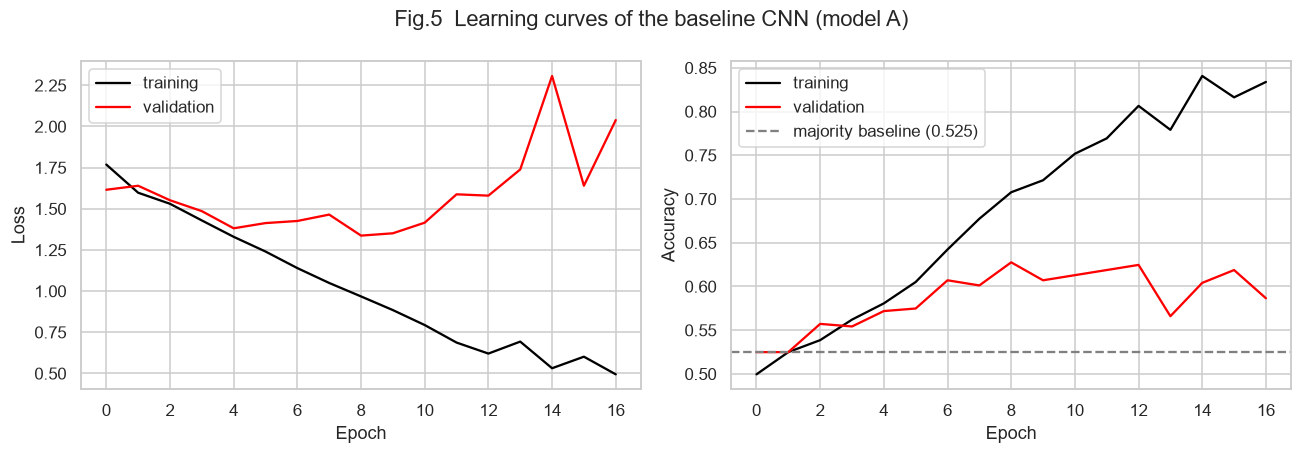

In [19]:
plot_learning_curves(baseline_history,
                     "Fig.5  Learning curves of the baseline CNN (model A)",
                     "fig05_learning_curve_baseline.png")

### モデルAの評価

検証データとテストデータの両方で評価します。テストデータは本来「最後に一度だけ」使うものですが、本ノートブックは教材なので、各段階での差を見せるために表示します。**モデルの選択にテストの数字を使わない**という原則を守ることが肝心です。

In [20]:
results = []

scores_val, _, _ = evaluate_classifier(baseline_model, X_val, y_val, "A: baseline CNN", "val")
scores_test, y_pred_baseline, _ = evaluate_classifier(
    baseline_model, X_test, y_test, "A: baseline CNN", "test")
results.extend([scores_val, scores_test])

print(pd.DataFrame([scores_val, scores_test]).round(4).to_string(index=False))
print(f"\nMajority-class baseline accuracy for reference: {majority_baseline:.4f}")

          model split  accuracy  balanced_accuracy  macro_f1  weighted_f1
A: baseline CNN   val    0.6276             0.3016    0.2912       0.5469
A: baseline CNN  test    0.6217             0.2961    0.2855       0.5387

Majority-class baseline accuracy for reference: 0.5249


In [21]:
print(classification_report(y_test, y_pred_baseline,
                            labels=range(NUM_CLASSES),
                            target_names=CATEGORIES, digits=3, zero_division=0))

                             precision    recall  f1-score   support

                 Biological      0.000     0.000     0.000        20
                     Fibres      0.000     0.000     0.000        20
       Films_Coated_Surface      0.571     0.200     0.296        20
MEMS_devices_and_electrodes      0.654     0.850     0.739        20
                  Nanowires      0.321     0.450     0.375        20
                  Particles      0.467     0.350     0.400        20
          Patterned_surface      0.143     0.050     0.074        20
              Porous_Sponge      0.667     0.100     0.174        20
                     Powder      0.680     0.961     0.796       179
                       Tips      0.000     0.000     0.000         2

                   accuracy                          0.622       341
                  macro avg      0.350     0.296     0.285       341
               weighted avg      0.522     0.622     0.539       341



### 図6：モデルAの混同行列

行方向に正規化しているので、各行の値は「その真のクラスのうち、何割がその列に予測されたか」＝**クラスごとの再現率**を表します。対角成分が濃いほど良いモデルです。

C:\Users\a013662\AppData\Local\Temp\ipykernel_1828\414949776.py:30: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  display_matrix = np.divide(matrix, row_sums, where=row_sums != 0)


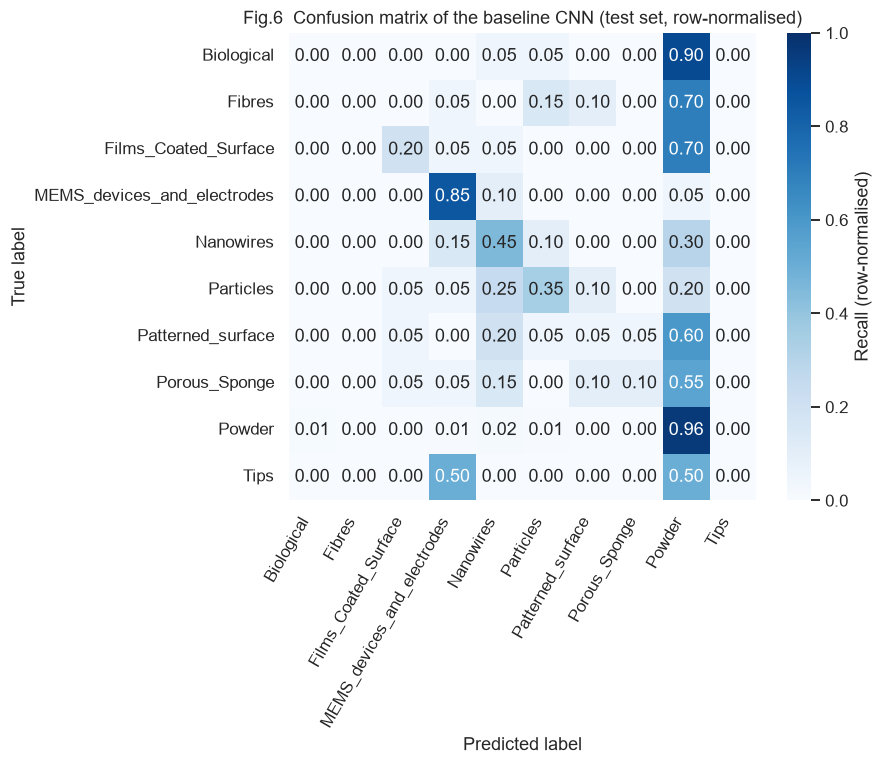

In [22]:
_ = plot_confusion_matrix(y_test, y_pred_baseline, CATEGORIES,
                          "Fig.6  Confusion matrix of the baseline CNN (test set, row-normalised)",
                          "fig06_confusion_baseline.png")

## 6. モデルの高度化 ― ハイパーパラメータ探索

畳み込み層の数、フィルタ数、全結合層の数を変えると精度はどう変わるのでしょうか。総当たり（グリッドサーチ）で確かめます。

1冊目では活性化関数・プーリング・最適化アルゴリズムという「部品」を入れ替えました。ここで探索するのは**構造そのもの**です。

**探索を行ううえで守るべき4つのルール**があります。実験計画としての要点なので、コードを読む前に押さえてください。

1. **選択には検証データだけを使う。** `validation_data` にテストデータを渡してはいけません。テストデータは探索が終わるまで一切触りません。触ってしまうと、報告する精度が実力より高く出ます。
2. **選択指標は macro-F1 にする。** クラス不均衡があるため、正解率の最大値で選ぶと「`Powder` を当てるのが上手いだけのモデル」が勝ってしまいます。
3. **「最良エポックの値」ではなく「復元後のモデルの性能」で比較する。** `max(history.history['val_accuracy'])` のような書き方は、たまたま良かった1エポックの値を拾ってしまいます（検証データへの過剰適合）。`EarlyStopping(restore_best_weights=True)` で最良時点に巻き戻したモデルを、あらためて評価します。
4. **構成ごとに乱数状態を揃える。** 初期値の当たり外れで順位が入れ替わっては、何を比較しているのか分からなくなります。`keras.utils.set_random_seed(SEED)` を各構成の直前で呼びます（1冊目のアブレーション実験と同じ考え方です）。

In [23]:
# 探索するハイパーパラメータの組み合わせ
CONV_BLOCKS = [1, 2, 3]      # 畳み込み＋プーリングのブロック数
LAYER_SIZES = [32, 64]       # 各層のフィルタ数／ユニット数
DENSE_LAYERS = [0, 1]        # 全結合の隠れ層の数

SEARCH_EPOCHS = 25
search_records = []
best_score = -np.inf
best_model = None
best_config = None

total = len(CONV_BLOCKS) * len(LAYER_SIZES) * len(DENSE_LAYERS)
print(f"Grid search over {total} configurations "
      f"(up to {SEARCH_EPOCHS} epochs each, early stopping enabled)\n")

search_start = time.time()
run_index = 0

for conv_blocks in CONV_BLOCKS:
    for layer_size in LAYER_SIZES:
        for dense_layers in DENSE_LAYERS:
            run_index += 1
            config_name = f"{conv_blocks}conv-{layer_size}filters-{dense_layers}dense"

            # 構成ごとに乱数状態を揃え、初期値の当たり外れによる差を減らす
            keras.utils.set_random_seed(SEED)

            model = build_simple_cnn(
                input_shape, NUM_CLASSES,
                conv_filters=tuple([layer_size] * conv_blocks),
                dense_units=tuple([layer_size] * dense_layers),
                name=config_name.replace("-", "_"))

            model.compile(
                optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                metrics=["accuracy"])

            history = model.fit(
                X_train, y_train,
                epochs=SEARCH_EPOCHS,
                batch_size=BATCH_SIZE,
                validation_data=(X_val, y_val),
                callbacks=[keras.callbacks.EarlyStopping(
                    monitor="val_loss", patience=5, restore_best_weights=True)],
                verbose=0)

            # restore_best_weights により最良エポックの重みに戻った状態で評価する
            scores, _, _ = evaluate_classifier(model, X_val, y_val, config_name, "val")
            scores.update({
                "conv_blocks": conv_blocks,
                "layer_size": layer_size,
                "dense_layers": dense_layers,
                "n_params": model.count_params(),
                "epochs_run": len(history.history["loss"]),
            })
            search_records.append(scores)

            print(f"[{run_index:2d}/{total}] {config_name:28s} "
                  f"val_acc={scores['accuracy']:.4f}  "
                  f"val_macroF1={scores['macro_f1']:.4f}  "
                  f"params={scores['n_params']:,}")

            if scores["macro_f1"] > best_score:
                best_score = scores["macro_f1"]
                best_model = model   # モデル本体を保持する（この代入を忘れやすい）
                best_config = scores.copy()

print(f"\nGrid search finished in {time.time() - search_start:.1f} s")
print(f"Best configuration: {best_config['model']} (val macro-F1 = {best_score:.4f})")

Grid search over 12 configurations (up to 25 epochs each, early stopping enabled)

[ 1/12] 1conv-32filters-0dense       val_acc=0.5718  val_macroF1=0.2151  params=3,073,610
[ 2/12] 1conv-32filters-1dense       val_acc=0.5748  val_macroF1=0.1880  params=9,835,178
[ 3/12] 1conv-64filters-0dense       val_acc=0.5689  val_macroF1=0.1902  params=6,147,210
[ 4/12] 1conv-64filters-1dense       val_acc=0.5601  val_macroF1=0.2128  params=39,339,338
[ 5/12] 2conv-32filters-0dense       val_acc=0.5836  val_macroF1=0.2452  params=716,458
[ 6/12] 2conv-32filters-1dense       val_acc=0.5425  val_macroF1=0.1146  params=2,271,946
[ 7/12] 2conv-64filters-0dense       val_acc=0.5748  val_macroF1=0.2399  params=1,451,338
[ 8/12] 2conv-64filters-1dense       val_acc=0.5865  val_macroF1=0.2417  params=9,086,346
[ 9/12] 3conv-32filters-0dense       val_acc=0.6188  val_macroF1=0.2900  params=159,946
[10/12] 3conv-32filters-1dense       val_acc=0.6100  val_macroF1=0.2469  params=470,762
[11/12] 3conv-64filter

In [24]:
search_df = (pd.DataFrame(search_records)
             .sort_values("macro_f1", ascending=False)
             .reset_index(drop=True))

search_df.to_csv(OUTPUT_DIR / "hyperparameter_search_results.csv", index=False)

display_columns = ["model", "conv_blocks", "layer_size", "dense_layers",
                   "n_params", "epochs_run", "accuracy", "balanced_accuracy", "macro_f1"]

print(search_df[display_columns].round(4).to_string(index=False))

                 model  conv_blocks  layer_size  dense_layers  n_params  epochs_run  accuracy  balanced_accuracy  macro_f1
3conv-64filters-0dense            3          64             0    356746          14    0.6129             0.2900    0.2962
3conv-32filters-0dense            3          32             0    159946          17    0.6188             0.2822    0.2900
3conv-64filters-1dense            3          64             1   1881546          17    0.6070             0.2933    0.2873
3conv-32filters-1dense            3          32             1    470762          18    0.6100             0.2583    0.2469
2conv-32filters-0dense            2          32             0    716458          12    0.5836             0.2444    0.2452
2conv-64filters-1dense            2          64             1   9086346          10    0.5865             0.2450    0.2417
2conv-64filters-0dense            2          64             0   1451338           9    0.5748             0.2605    0.2399
1conv-32filters-

### 図7：ハイパーパラメータ探索の結果

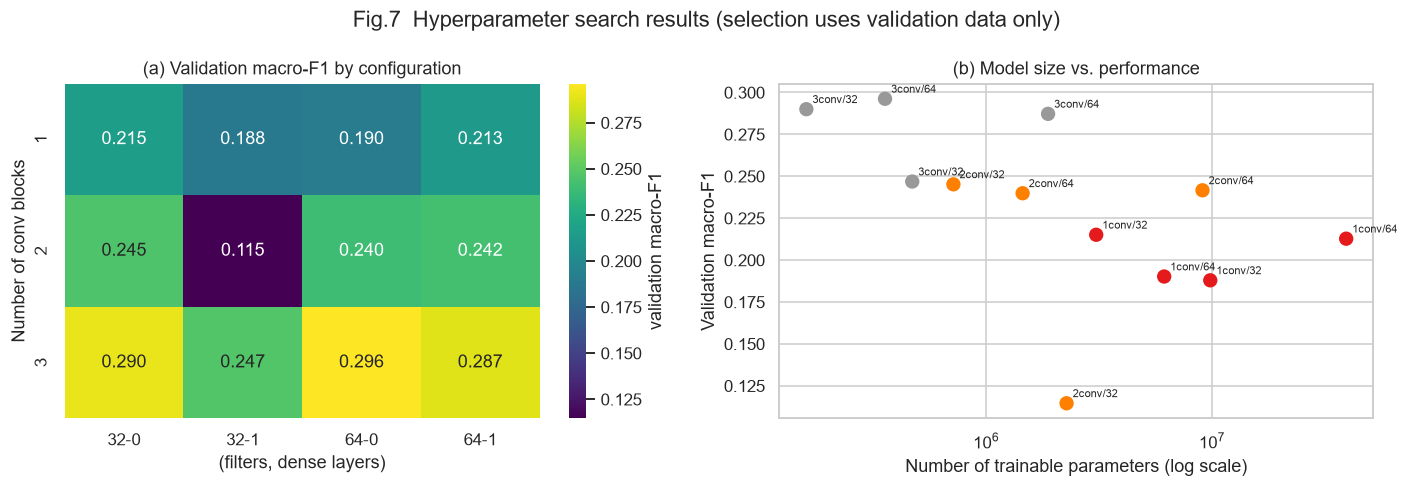

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

pivot = search_df.pivot_table(index="conv_blocks", columns=["layer_size", "dense_layers"],
                              values="macro_f1")
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[0],
            cbar_kws={"label": "validation macro-F1"})

axes[0].set_title("(a) Validation macro-F1 by configuration")
axes[0].set_xlabel("(filters, dense layers)")
axes[0].set_ylabel("Number of conv blocks")

axes[1].scatter(search_df["n_params"], search_df["macro_f1"],
                s=70, c=search_df["conv_blocks"], cmap="Set1")
for _, row in search_df.iterrows():
    axes[1].annotate(row["model"].split("-")[0] + "/" + str(row["layer_size"]),
                     (row["n_params"], row["macro_f1"]),
                     fontsize=7, xytext=(4, 4), textcoords="offset points")

axes[1].set_xscale("log")
axes[1].set_xlabel("Number of trainable parameters (log scale)")
axes[1].set_ylabel("Validation macro-F1")
axes[1].set_title("(b) Model size vs. performance")

fig.suptitle("Fig.7  Hyperparameter search results (selection uses validation data only)")
fig.tight_layout()

fig.savefig(OUTPUT_DIR / "fig07_hyperparameter_search.png", dpi=150)
plt.show()

> **読み取りのヒント**：パラメータ数が多いモデルほど良いとは限りません。畳み込みブロックが少ないと `Flatten` 後の次元が跳ね上がり、全結合層のパラメータが爆発して過学習しやすくなります。「小さいモデルのほうが強い」という結果が出たら、それはデータ量（訓練1,023枚）に対してモデルが大きすぎたということです。

### 最良モデルの保存と読み込み

探索で選ばれたモデルをファイルに保存します。保存先のパスは**明示的に指定**してください。「`model/` フォルダの中で更新時刻が最も新しいファイルを読む」といった実装は、フォルダに他のモデルが残っていると誤ったモデルを読み込むため危険です。

保存したあと読み直して同じ結果になることを確認する「往復テスト」も入れています（1冊目の6.4節と同じ考え方です）。

In [26]:
best_model_path = MODEL_DIR / "best_cnn.keras"
best_model.save(best_model_path)

metadata = {k: v for k, v in best_config.items() if k not in ("model", "split")}
pd.Series(metadata).to_json(MODEL_DIR / "best_cnn_config.json", indent=2)

print(f"Saved best model to: {best_model_path}")
print(f"Configuration: {best_config['model']}")

# 保存したファイルから読み直し、同じ結果になることを確認する
reloaded_model = keras.models.load_model(best_model_path)
reload_scores, _, _ = evaluate_classifier(reloaded_model, X_val, y_val, "reloaded", "val")
print(f"\nSanity check -- val macro-F1 before save: {best_config['macro_f1']:.6f}")
print(f"Sanity check -- val macro-F1 after reload: {reload_scores['macro_f1']:.6f}")

Saved best model to: c:\Users\a013662\Dropbox\ARIM\1_ARIM-Academy-ImageRecognition\Advanced_Tutorial_1_SEM-Image-Classification\model\best_cnn.keras
Configuration: 3conv-64filters-0dense

Sanity check -- val macro-F1 before save: 0.296244
Sanity check -- val macro-F1 after reload: 0.296244


### 図8・図9：最良モデルの再学習と評価

探索では最大25エポックで打ち切っていました。選ばれた構成をもう一度、じっくり（最大60エポック、EarlyStopping付き）学習させます。

> **なぜ訓練データだけで再学習するのか**：本来は「構成が決まったら訓練＋検証をまとめて再学習し、テストで最終評価する」のが最もデータを有効活用できます。ただし、それでは EarlyStopping の打ち切り判断に使う検証データが無くなります。本ノートブックは教材としての分かりやすさを優先し、訓練データのみで再学習し検証データで打ち切る構成にしています。

Epoch 1/60
16/16 - 10s - 639ms/step - accuracy: 0.4985 - loss: 1.7782 - val_accuracy: 0.5249 - val_loss: 1.6554
Epoch 2/60
16/16 - 9s - 551ms/step - accuracy: 0.5259 - loss: 1.6331 - val_accuracy: 0.5484 - val_loss: 1.6572
Epoch 3/60
16/16 - 9s - 571ms/step - accuracy: 0.5425 - loss: 1.5355 - val_accuracy: 0.5689 - val_loss: 1.5608
Epoch 4/60
16/16 - 10s - 641ms/step - accuracy: 0.5572 - loss: 1.4775 - val_accuracy: 0.5425 - val_loss: 1.5279
Epoch 5/60
16/16 - 9s - 572ms/step - accuracy: 0.5699 - loss: 1.4334 - val_accuracy: 0.5630 - val_loss: 1.4432
Epoch 6/60
16/16 - 8s - 508ms/step - accuracy: 0.5836 - loss: 1.3565 - val_accuracy: 0.5630 - val_loss: 1.3903
Epoch 7/60
16/16 - 10s - 599ms/step - accuracy: 0.6158 - loss: 1.2521 - val_accuracy: 0.5689 - val_loss: 1.3582
Epoch 8/60
16/16 - 9s - 537ms/step - accuracy: 0.6481 - loss: 1.1675 - val_accuracy: 0.5865 - val_loss: 1.3704
Epoch 9/60
16/16 - 8s - 476ms/step - accuracy: 0.6882 - loss: 1.0287 - val_accuracy: 0.6129 - val_loss: 1.285

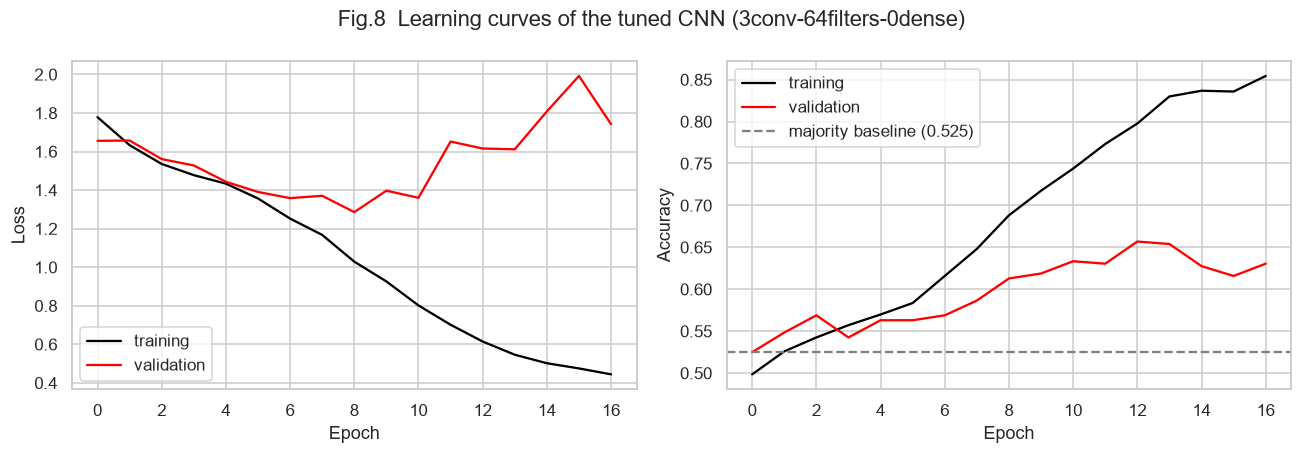

In [27]:
keras.utils.set_random_seed(SEED)

tuned_model = build_simple_cnn(
    input_shape, NUM_CLASSES,
    conv_filters=tuple([best_config["layer_size"]] * best_config["conv_blocks"]),
    dense_units=tuple([best_config["layer_size"]] * best_config["dense_layers"]),
    name="tuned_cnn")

tuned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"])

tuned_history = tuned_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[
        keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                      restore_best_weights=True, verbose=1),
        keras.callbacks.ModelCheckpoint(MODEL_DIR / "tuned_cnn.keras",
                                        monitor="val_loss", save_best_only=True),
    ],
    verbose=2)

plot_learning_curves(tuned_history,
                     f"Fig.8  Learning curves of the tuned CNN ({best_config['model']})",
                     "fig08_learning_curve_tuned.png")

In [28]:
scores_val_tuned, _, _ = evaluate_classifier(tuned_model, X_val, y_val, "B: tuned CNN", "val")
scores_test_tuned, y_pred_tuned, _ = evaluate_classifier(
    tuned_model, X_test, y_test, "B: tuned CNN", "test")
results.extend([scores_val_tuned, scores_test_tuned])

print(pd.DataFrame([scores_val_tuned, scores_test_tuned]).round(4).to_string(index=False))
print()
print(classification_report(y_test, y_pred_tuned, labels=range(NUM_CLASSES),
                            target_names=CATEGORIES, digits=3, zero_division=0))

       model split  accuracy  balanced_accuracy  macro_f1  weighted_f1
B: tuned CNN   val    0.6129             0.2900    0.2962       0.5433
B: tuned CNN  test    0.6217             0.3005    0.3164       0.5590

                             precision    recall  f1-score   support

                 Biological      0.400     0.100     0.160        20
                     Fibres      0.333     0.050     0.087        20
       Films_Coated_Surface      0.800     0.200     0.320        20
MEMS_devices_and_electrodes      0.667     0.700     0.683        20
                  Nanowires      0.357     0.250     0.294        20
                  Particles      0.400     0.400     0.400        20
          Patterned_surface      0.333     0.250     0.286        20
              Porous_Sponge      0.200     0.100     0.133        20
                     Powder      0.690     0.955     0.801       179
                       Tips      0.000     0.000     0.000         2

                   accura

C:\Users\a013662\AppData\Local\Temp\ipykernel_1828\414949776.py:30: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  display_matrix = np.divide(matrix, row_sums, where=row_sums != 0)


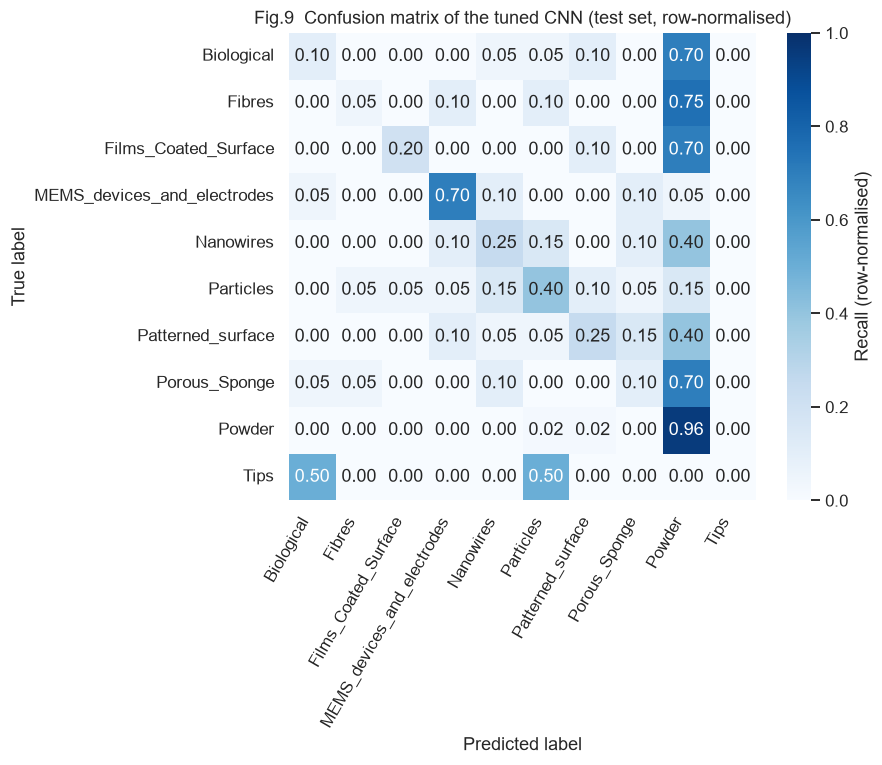

In [29]:
_ = plot_confusion_matrix(y_test, y_pred_tuned, CATEGORIES,
                          "Fig.9  Confusion matrix of the tuned CNN (test set, row-normalised)",
                          "fig09_confusion_tuned.png")

## 7. モデル比較

多数派ベースライン、モデルA（ベースラインCNN）、モデルB（探索で選ばれたCNN）を、**1冊目のLeNet-5と同じテストデータで**比較します。1冊目が出力した `output/model_comparison_lenet.csv` があれば自動的に読み込みます（無くてもエラーにはなりません）。

In [30]:
# 多数派クラスを常に予測するだけの「モデル」を評価に加える
majority_class = int(pd.Series(y_train).value_counts().idxmax())
y_pred_majority = np.full_like(y_test, majority_class)

baseline_row = {
    "model": "0: majority-class baseline",
    "split": "test",
    "accuracy": accuracy_score(y_test, y_pred_majority),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_majority),
    "macro_f1": f1_score(y_test, y_pred_majority, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, y_pred_majority, average="weighted", zero_division=0),
}

rows = [baseline_row] + [r for r in results if r["split"] == "test"]

# 1冊目（LeNet-5）の結果があれば読み込んで並べる
lenet_csv = OUTPUT_DIR / "model_comparison_lenet.csv"
if lenet_csv.exists():
    lenet_results = pd.read_csv(lenet_csv)
    # 多数派ベースラインは重複するので除外して結合する
    lenet_results = lenet_results[~lenet_results["model"].str.startswith("0:")]
    rows = rows + lenet_results.to_dict("records")
    print(f"Loaded {len(lenet_results)} result(s) from {lenet_csv.name}")
else:
    print(f"{lenet_csv.name} not found -- run 1_LeNet-5.ipynb to include "
          f"the LeNet-5 results in the comparison.")

comparison = (pd.DataFrame(rows)
              .drop_duplicates(subset=["model", "split"])
              .sort_values("macro_f1", ascending=False)
              .reset_index(drop=True))
comparison.to_csv(OUTPUT_DIR / "model_comparison_cnn.csv", index=False)
print()
print(comparison.round(4).to_string(index=False))

Loaded 2 result(s) from model_comparison_lenet.csv

                                              model split  accuracy  balanced_accuracy  macro_f1  weighted_f1
                                       B: tuned CNN  test    0.6217             0.3005    0.3164       0.5590
                                    A: baseline CNN  test    0.6217             0.2961    0.2855       0.5387
2: LeNet-5 modernised (+ ReLU + max pooling + Adam)  test    0.5660             0.2144    0.2290       0.4792
                              1: LeNet-5 (original)  test    0.5249             0.1178    0.1022       0.3883
                         0: majority-class baseline  test    0.5249             0.1000    0.0688       0.3614


### 図10：テストデータでのモデル比較

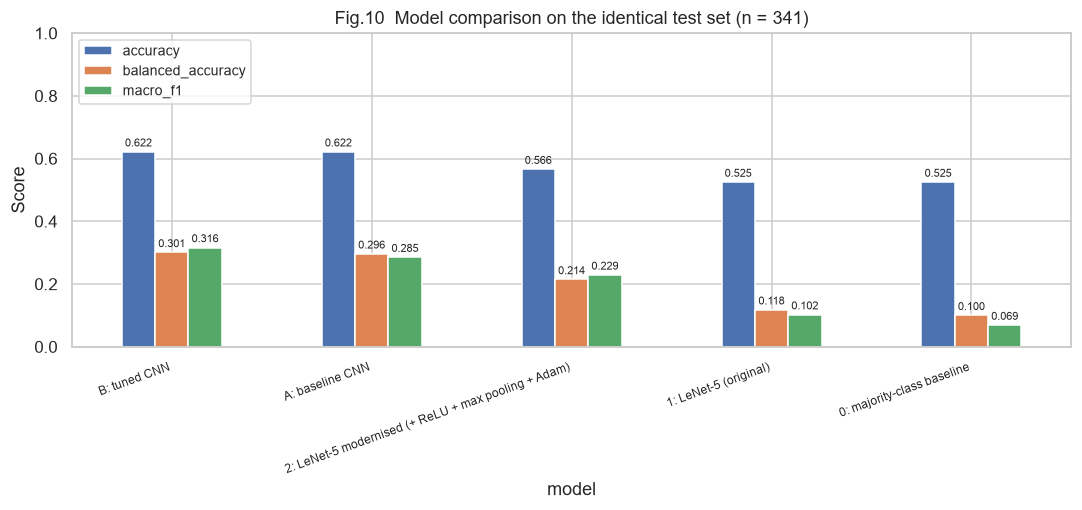

In [31]:
metrics_to_plot = ["accuracy", "balanced_accuracy", "macro_f1"]
plot_df = comparison.set_index("model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(10, 4.8))
plot_df.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_title(f"Fig.10  Model comparison on the identical test set (n = {len(y_test)})")
ax.tick_params(axis="x", rotation=20)
plt.setp(ax.get_xticklabels(), ha="right", fontsize=8)
ax.legend(loc="upper left", fontsize=9)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig10_model_comparison.png", dpi=150)
plt.show()

> **読み取りのヒント**：多数派ベースラインは accuracy こそ 0.52 ありますが、balanced accuracy は 0.10（＝1/10）、macro-F1 は 0.07 程度しかありません。3つの指標を並べて初めて「そのモデルが本当に10クラスを見分けられているのか」が分かります。accuracy だけを報告するのは、不均衡データでは不誠実な報告になり得ます。
>
> **1冊目のLeNet-5と比べる**：LeNet-5の行が表に入っていれば、32×32・6/16チャンネルの1998年設計と、100×100・32/64チャンネルの現代設計の差がそのまま読み取れます。この差は「アルゴリズムの進歩」だけでなく「入力解像度」「チャンネル数」「最適化」が**合わさった**結果である点に注意してください。どれか1つの寄与を切り分けたければ、1冊目の第8章のようなアブレーション実験が必要です。

## 8. 未知の画像に対する予測

学習に使っていない画像（`data/prediction_data/`）を分類させてみます。

**推論時の前処理は、学習時とまったく同じでなければなりません。** これは深層学習で最も見つけにくいバグの原因です。「学習時は255で割ったのに、推論時に割り忘れた」というだけで、入力の分布がまるで違うものになり、モデルは意味のない答えを返します。しかもエラーは出ないので気づけません。

本書ではこの事故を2重に防いでいます。

1. スケーリング（0〜255 → 0〜1）を**モデル内部の `Rescaling` 層**に持たせる → 推論時に割り忘れようがない
2. 画像の読み込み・情報バー除去・リサイズを、学習時と**同じ `load_micrograph()`** に通す → 前処理の食い違いが起こりようがない

また、最も確率の高いクラス名だけでなく**上位3クラスと確率**を表示します。モデルがどれくらい迷っているかが分かり、実務では「確信度が低ければ人間が確認する」という運用につなげられます。

In [32]:
def predict_micrograph(model, path, class_names, top_k=3):
    """1枚のSEM画像を分類し、上位k件の (クラス名, 確率) と前処理後の画像を返す。

    前処理は学習時と完全に同じ load_micrograph() を使う（前処理の食い違いを防ぐ）。
    """
    image = load_micrograph(path)                      # (H, W, 1) uint8
    batch = image[np.newaxis, ...]                     # (1, H, W, 1)
    proba = predict_proba(model, batch)[0]
    order = np.argsort(proba)[::-1][:top_k]
    return [(class_names[i], float(proba[i])) for i in order], image


prediction_paths = sorted(PREDICT_DIR.glob("*.jpg"))
print(f"Found {len(prediction_paths)} image(s) for prediction:")
for path in prediction_paths:
    print(f"  - {path.name}")

Found 2 image(s) for prediction:
  - biology.jpg
  - fiber.jpg


### 図11：未知画像の予測結果

biology.jpg: Biological (0.351), Powder (0.214), Films_Coated_Surface (0.123)
fiber.jpg: Powder (0.228), Fibres (0.183), Biological (0.127)


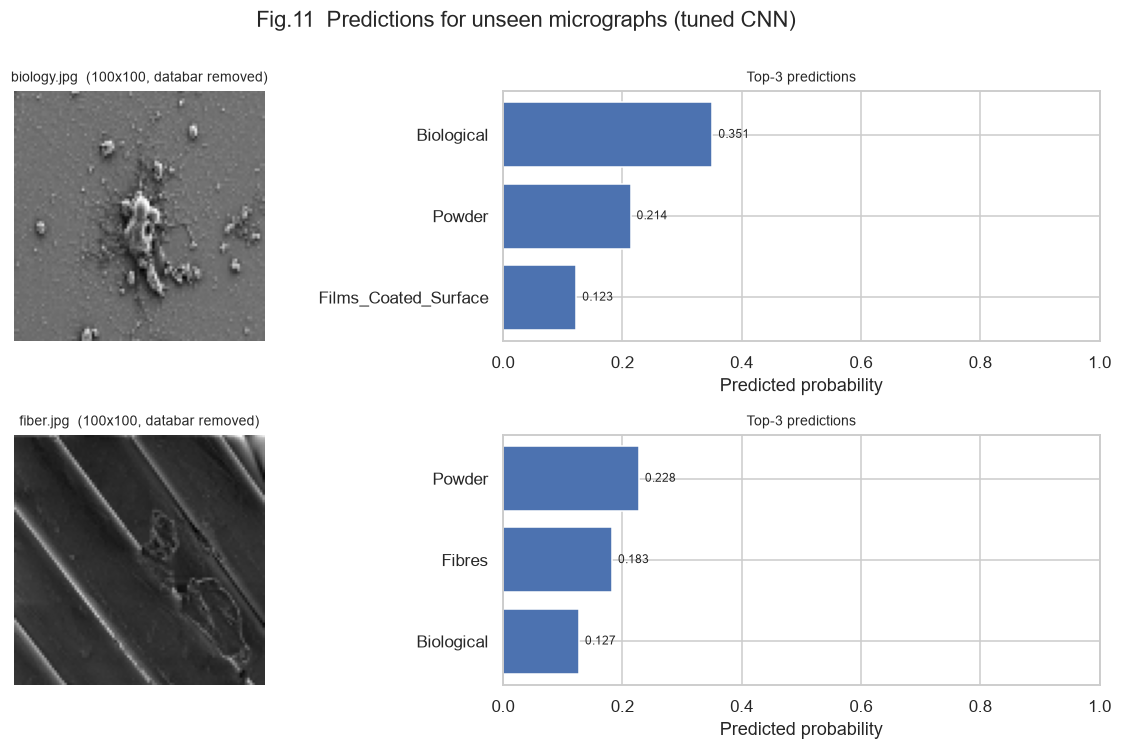

In [33]:
fig, axes = plt.subplots(len(prediction_paths), 2,
                         figsize=(11, 3.4 * len(prediction_paths)),
                         gridspec_kw={"width_ratios": [1, 1.5]})
axes = np.atleast_2d(axes)

for row, path in enumerate(prediction_paths):
    top_predictions, processed = predict_micrograph(tuned_model, path, CATEGORIES)

    axes[row, 0].imshow(processed.squeeze(), cmap="gray")
    axes[row, 0].set_title(f"{path.name}  ({IMG_SIZE}x{IMG_SIZE}, databar removed)", fontsize=9)
    axes[row, 0].axis("off")

    names = [n for n, _ in top_predictions][::-1]
    values = [v for _, v in top_predictions][::-1]
    axes[row, 1].barh(names, values, color="#4C72B0")
    axes[row, 1].set_xlim(0, 1)
    axes[row, 1].set_xlabel("Predicted probability")
    axes[row, 1].set_title("Top-3 predictions", fontsize=9)
    for y_pos, value in enumerate(values):
        axes[row, 1].text(value + 0.01, y_pos, f"{value:.3f}", va="center", fontsize=8)

    print(f"{path.name}: " +
          ", ".join(f"{n} ({v:.3f})" for n, v in top_predictions))

fig.suptitle("Fig.11  Predictions for unseen micrographs (tuned CNN)", y=1.0)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig11_unseen_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

> **結果の解釈に関する注意**：`data/prediction_data/` の2枚は、原データセットと同じ装置・同じ撮影条件で得られた画像です。したがって、ここで正解したからといって「別の研究室のSEMで撮った画像でも当たる」ことにはなりません。装置や試料調製が変わると精度が大きく落ちる現象を **ドメインシフト** と呼び、実運用で最初にぶつかる壁です。

## 9. まとめ

本ノートブックで確認したことを整理します。

1. **データを先に見る。** 配布データは全21,272枚のうち1,705枚の抜粋で、`Powder` が52.5%、`Tips` は0.6%という強い不均衡がありました。この事実を知らずに正解率だけを見ると、モデルの実力を大きく誤認します。
2. **SEM画像には情報バーが焼き込まれている。** 前処理で切り落とさないと、CNNが試料の形態ではなく文字を手がかりにしてしまう恐れがあります（ショートカット学習）。
3. **訓練・検証・テストは3つに分ける。** ハイパーパラメータの選択に使ったデータで最終評価をしてはいけません。`stratify` を付けないと、少数クラスが特定の分割に偏ります。
4. **不均衡データでは正解率だけを見ない。** balanced accuracy と macro-F1、そして多数派ベースラインを必ず併記します。
5. **前処理はモデルに内蔵する。** `Rescaling` 層を使うことで、「学習時と推論時で前処理が食い違う」という最も見つけにくいバグを構造的に防げます。
6. **大きいモデルが良いとは限らない。** 訓練データが1,023枚しかない状況では、パラメータの多いモデルほど過学習しやすくなります。

### LeNet-5から何が変わったのか（1冊目との接続）

| | LeNet-5（1冊目） | 本書のCNN |
| --- | --- | --- |
| 設計思想 | 1998年の制約下での最適解 | 現代の部品で組み直した小規模CNN |
| 入力 | 32×32 | 100×100 |
| 畳み込み | 6ch → 16ch（2層） | 32ch → 64ch → 64ch（3層） |
| 活性化 / プーリング / 最適化 | tanh / 平均 / SGD | ReLU / 最大 / Adam |
| 設計の決め方 | 論文の固定構成 | 検証データによる総当たり探索 |
| 変わらないもの | **畳み込み→プーリング→…→平坦化→全結合という骨格**、局所受容野・重み共有・サブサンプリングという3つの発想 | |

**骨格が変わっていないことが重要です。** 30年近く経っても、LeNet-5が示した設計原理はそのまま生きています。変わったのは、その骨格をどこまで大きく・深くできるかを可能にした周辺技術（活性化関数、最適化、正則化、計算資源）のほうです。

### 本ノートブックで扱っていないこと（今後の課題）

- **データ拡張（data augmentation）**：回転・反転・明るさ変更などで訓練データを水増しする手法。SEM画像では上下反転が物理的に不自然な場合があるなど、ドメイン固有の判断が必要です。
- **クラス不均衡への直接的な対処**：`class_weight` による損失の重み付け、少数クラスのオーバーサンプリング、Focal Loss など。本ノートブックは指標の側で不均衡に対処するに留めました。
- **交差検証（cross-validation）**：単一の分割による評価は、分割の運不運に左右されます。特に `Tips` のようにテストデータが2枚しかないクラスでは、層化k分割交差検証のほうが信頼できる推定になります。
- **転移学習**：ImageNetで事前学習した大規模モデルを流用する手法。→ **`3_Xception.ipynb` で扱います。**
- **モデルの説明性**：Grad-CAM などで「画像のどこを見て判断したか」を可視化する手法。情報バーを消し忘れていないかの検算にも使えます。
- **解像度のさらなる向上**：本ノートブックは 100×100 に固定しましたが、これが最適という保証はありません（演習2で確かめます）。
- **統計的な有意差の検定**：モデル間の macro-F1 の差が偶然の範囲かどうかは検定していません。

## 10. 演習問題

### 演習1（基礎）：情報バーを残すと何が起きるか
`load_micrograph()` の `crop_databar` を `False` にしてデータセットを作り直し、モデルAを学習させてください。テストの macro-F1 は上がりますか、下がりますか。上がった場合、それを「性能が改善した」と報告してよいでしょうか。理由とともに説明してください。

### 演習2（基礎）：入力解像度の影響
`IMG_SIZE` を 64 と 150 に変えて、モデルAの macro-F1 と学習時間を比較してください。どのカテゴリが解像度低下の影響を最も受けますか。図3を見ながら考察してください。1冊目のLeNet-5（32×32）の結果も並べると、解像度が効くのか層構成が効くのかを切り分けるヒントになります。

### 演習2b（基礎）：LeNet-5を100×100で動かす
1冊目の `build_lenet5()` を `input_shape=(100, 100, 1)` で構築し、本書と同じ訓練データで学習させてください。パラメータ数は何個になりますか（`Flatten` 前の特徴マップの大きさから手計算し、`summary()` と照合してください）。本書のCNNとの差は「解像度」によるものでしたか、それとも「層構成とチャンネル数」によるものでしたか。

### 演習3（応用）：クラス重み付け
`model.fit()` に `class_weight` 引数を渡して、少数クラスの誤りを重く扱ってみてください。重みは次のように計算できます。

```python
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight = dict(enumerate(weights))
```

accuracy と balanced accuracy はそれぞれどう変化しましたか。トレードオフを説明してください。

### 演習4（応用）：データ拡張
`keras.layers.RandomFlip("horizontal")` と `keras.layers.RandomRotation(0.1)` をモデルの先頭（`Rescaling` の直後）に追加して学習し直してください。過学習は緩和されましたか。また、SEM画像に対して**適用すべきでない**拡張を1つ挙げ、その理由を述べてください。

### 演習5（発展）：交差検証による安定性の評価
`sklearn.model_selection.StratifiedKFold` で5分割交差検証を行い、macro-F1 の平均と標準偏差を求めてください。単一分割で得た値は、その範囲に収まっていますか。

### 演習6（発展）：混同しやすいカテゴリの分析
図9の混同行列で、最も混同されているカテゴリの組を特定してください。実際に誤分類された画像を数枚表示し、人間の目でも区別が難しいかどうかを確認してください。分類体系そのものに改善の余地はありますか。

---

### 次のノートブック

ここまでの2冊は、いずれも**手元の1,023枚だけで、重みをランダムな初期値から学習**してきました。この枚数で「エッジを検出する」「テクスチャを捉える」といった画像認識の基礎能力をゼロから覚えさせるのは、かなり無理があります。

**`3_Xception.ipynb`** では発想を変え、**ImageNetの約1,400万枚で学習済みのモデルを借りてくる**転移学習を扱います。本書で作った評価の枠組み（3分割・macro-F1・多数派ベースライン）と、同一のテストデータをそのまま使うので、「ゼロから学習した小規模CNN」と「事前学習済み大規模モデル」を公平に比較できます。

| | 1_LeNet-5 | 2_CNN（本書） | 3_Xception |
| --- | --- | --- | --- |
| 入力 | 32×32 | 100×100 | 128×128（RGB） |
| パラメータ数 | 約6万 | 数十万〜数百万 | 約2,100万 |
| 重みの出どころ | ランダム初期値 | ランダム初期値 | **ImageNet事前学習** |

### 出力ファイル一覧

| ファイル | 内容 |
| --- | --- |
| `output/sem_dataset_gray_100.npz` | 前処理済みデータセット（キャッシュ） |
| `output/fig01〜fig11_*.png` | 本ノートブックの全図 |
| `output/hyperparameter_search_results.csv` | ハイパーパラメータ探索の全結果 |
| `output/model_comparison_cnn.csv` | テストデータでのモデル比較（次冊が読み込む） |
| `model/baseline_cnn.keras` | モデルA（ベースラインCNN） |
| `model/best_cnn.keras`, `model/tuned_cnn.keras` | モデルB（探索で選ばれた構成） |
| `model/best_cnn_config.json` | 選ばれた構成のメタデータ |

### 参考文献

[1] R. Aversa, M. H. Modarres, S. Cozzini, R. Ciancio, A. Chiusole, *The first annotated set of scanning electron microscopy images for nanoscience*, **Scientific Data 5, 180172 (2018)**, DOI: [10.1038/sdata.2018.172](https://doi.org/10.1038/sdata.2018.172)

[2] Y. LeCun, L. Bottou, Y. Bengio, P. Haffner, *Gradient-based learning applied to document recognition*, **Proceedings of the IEEE 86(11), 2278–2324 (1998)**, DOI: [10.1109/5.726791](https://doi.org/10.1109/5.726791)